La visualisation des données est essentielle en analyse car elle traduit des données brutes complexes en représentations graphiques, permettant au cerveau humain de traiter l'information bien plus rapidement qu'avec de simples tableaux de chiffres. Elle facilite la détection immédiate des tendances, des corrélations et des anomalies cachées, tout en simplifiant la communication des résultats pour une prise de décision rapide et accessible à tous.

Dans ce contexte, le graphique linéaire a pour but principal de montrer l'évolution d'une variable sur une période de temps continue. En reliant les points de données, il permet de suivre facilement une trajectoire (hausse, baisse ou stabilité), de repérer des cycles saisonniers et de comparer l'évolution de plusieurs catégories en un seul coup d'œil.

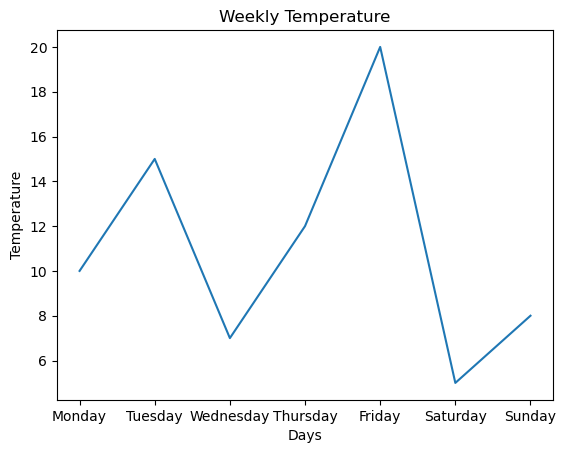

In [8]:
import matplotlib.pyplot as plt

days=["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
Temp=[10, 15, 7, 12, 20, 5, 8]
plt.plot(days,Temp)
plt.xlabel("Days")
plt.ylabel("Temperature")
plt.title("Weekly Temperature")
plt.show()


In [ ]:
months = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

sales=[5000, 5500, 6200, 7000, 7500]

plt.bar(months, sales)
plt.xlabel("Months")
plt.ylabel("Sales")
plt.title("Monthly Sales")
plt.show()

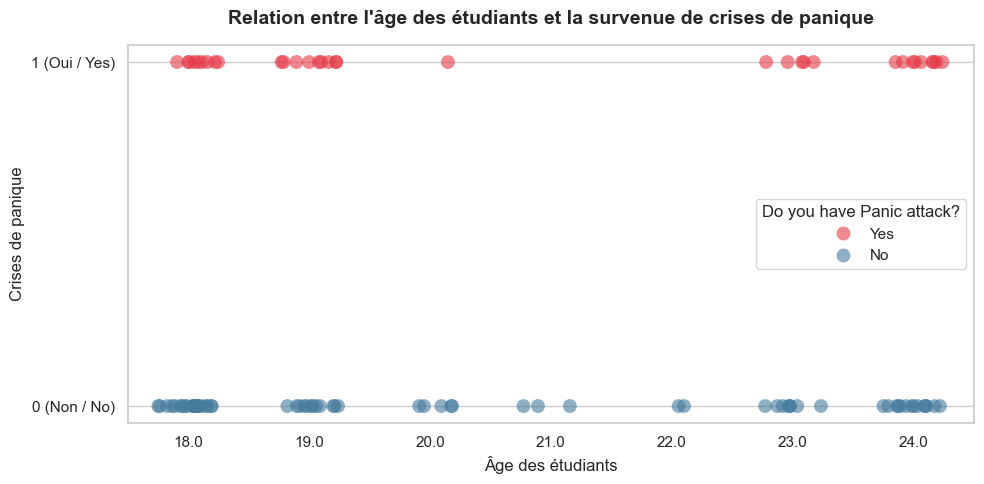

In [ ]:
from io import BytesIO
from urllib.request import urlopen
from zipfile import ZipFile

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 1. Télécharger et lire le fichier ZIP
url = "https://github.com/devtlv/Datasets-GEN-AI-Bootcamp/raw/refs/heads/main/Week%203/W3D1%20-%20Data%20Visualization/Student%20Mental%20health.zip"
response = urlopen(url)
zipfile = ZipFile(BytesIO(response.read()))
csv_file_name = zipfile.namelist()[0]

# Lire le CSV avec l'encodage latin1
df = pd.read_csv(zipfile.open(csv_file_name), encoding="latin1")

# Nettoyage préventif des colonnes au cas où il y aurait des espaces cachés
df.columns = df.columns.str.strip()

# Conversion en valeurs numériques
df["Crises_Numerique"] = df["Do you have Panic attack?"].map({"Yes": 1, "No": 0})

# Configuration du style graphique
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 5))

# MODIFICATION ICI : On utilise stripplot pour activer le "jitter" automatique
sns.stripplot(
    data=df,
    x="Age",
    y="Crises_Numerique",
    hue="Do you have Panic attack?",
    palette={"Yes": "#E63946", "No": "#457B9D"},
    size=10,  # Équivalent de 's' dans scatterplot
    alpha=0.6,
    jitter=0.25,  # Gère la dispersion horizontale de manière fluide
    dodge=False,  # Garde les points Oui/Non sur le même axe d'âge
)

# 5. Personnalisation des étiquettes et du titre
plt.title(
    "Relation entre l'âge des étudiants et la survenue de crises de panique",
    fontsize=14,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Âge des étudiants", fontsize=12)
plt.ylabel("Crises de panique", fontsize=12)

# Remplacement des graduations par des labels clairs
plt.yticks([0, 1], ["0 (Non / No)", "1 (Oui / Yes)"])

# Affichage du graphique
plt.tight_layout()
plt.show()

df.mis

C:\Users\Debohi\AppData\Local\Temp\ipykernel_35692\2475597297.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


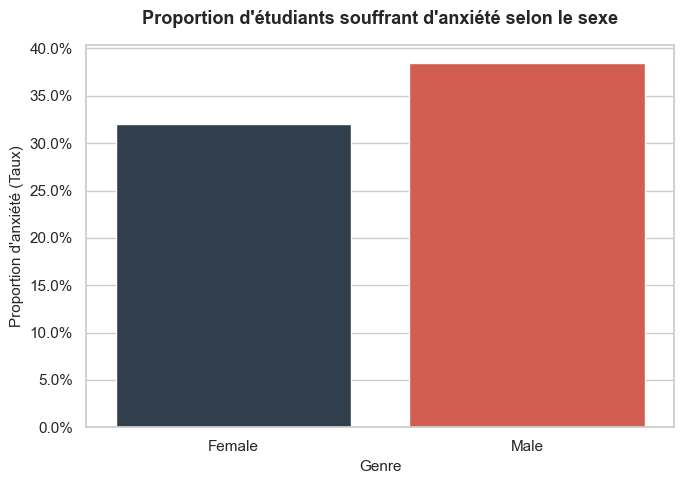

In [17]:
df.columns = df.columns.str.strip()
df["Do you have Anxiety?"] = df["Do you have Anxiety?"].str.strip()
df["Choose your gender"] = df["Choose your gender"].str.strip()

# --- Calcul des proportions d'anxiété par genre ---
# On crée une colonne booléenne (1 si Anxiété 'Yes', 0 sinon) pour calculer facilement le taux
df["Anxiety_Rate"] = (df["Do you have Anxiety?"] == "Yes").astype(int)

# Configuration du style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(7, 5))

# 2 & 3. Créer le graphique à barres et personnaliser la palette
# L'argument 'errorbar=None' retire les barres d'erreur pour une meilleure lisibilité
sns.barplot(
    data=df,
    x="Choose your gender",
    y="Anxiety_Rate",
    palette=["#2c3e50", "#e74c3c"],  # Palette sobre et contrastée
    errorbar=None,
)

# Personnalisation des titres et labels
plt.title(
    "Proportion d'étudiants souffrant d'anxiété selon le sexe",
    fontsize=13,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Genre", fontsize=11)
plt.ylabel("Proportion d'anxiété (Taux)", fontsize=11)

# Optionnel : Convertir l'axe Y en pourcentages pour une lecture plus naturelle
import matplotlib.ticker as mtick

plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

# 4. Afficher l'intrigue
plt.tight_layout()
plt.show()

C:\Users\Debohi\AppData\Local\Temp\ipykernel_35692\430363696.py:15: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(


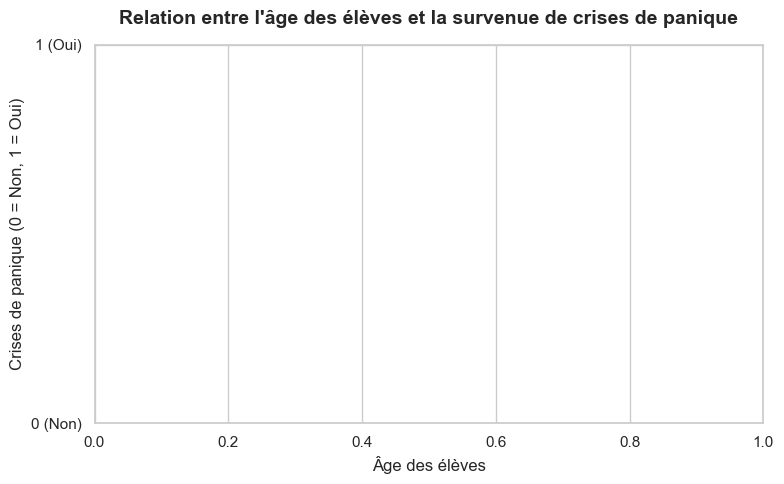

In [25]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 2. Conversion des réponses textuelles en valeurs numériques (Oui=1, Non=0)
df["Do you have Anxiety?"] = df["Do you have Anxiety?"].map(
    {"Oui": 1, "Non": 0}
)

# Configuration du style Seaborn
sns.set_theme(style="whitegrid")

# 3. Création du nuage de points avec personnalisation
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df,
    x="Age",
    y="Do you have Anxiety?",
    hue="Do you have Anxiety?",  # Colore les points selon la réponse originale
    palette={"Oui": "#E63946", "Non": "#457B9D"},  # Couleurs personnalisées
    s=100,  # Augmente la taille des points
    alpha=0.7,  # Ajoute de la transparence pour voir les superpositions
    x_jitter=0.1,  # Légère dispersion horizontale pour mieux voir les points du même âge
    y_jitter=0.05,  # Légère dispersion verticale pour éviter l'alignement strict sur 0 et 1
)

# 4. Personnalisation des axes et du titre
plt.title(
    "Relation entre l'âge des élèves et la survenue de crises de panique",
    fontsize=14,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Âge des élèves", fontsize=12)
plt.ylabel("Crises de panique (0 = Non, 1 = Oui)", fontsize=12)

# Ajustement des graduations de l'axe Y pour afficher clairement 0 et 1
plt.yticks([0, 1], ["0 (Non)", "1 (Oui)"])

# 5. Affichage du graphique
plt.tight_layout()
plt.show()